# Experimentos con el subconjunto de 10 clases — Pipeline completo

## Objetivo del notebook

Este notebook replica y extiende el pipeline de `dataExperiments.ipynb` pero trabaja **exclusivamente** con el subconjunto filtrado de 10 clases más reconocibles (seleccionadas por F1-score) del dataset UCF101.

## Ventajas del enfoque 10-clases

- **Convergencia más rápida**: 100+ clases → 10 clases reduce la complejidad del problema.
- **Mayor generalización**: menos overfitting en clases minoritarias.
- **Mejor interpretabilidad**: confusiones entre 10 clases vs. 100+ son más análisis.
- **Reproducibilidad**: acciones claramente diferenciables, menos ambigüedad motora.

## Flujo principal

1. **Carga del pickle filtrado**: lectura desde `Dataset/ucf101_2d_10cls.pkl` (pre-procesado).
2. **Exploración de datos**: DataFrame resumen, distribución de clases, pre-conversión de keypoints.
3. **Definir Dataset y Transforms**: `UCFSkeletonDataset` con normalización.
4. **Collate y DataLoader**: padding temporal derecho (right-pad), batch assembly.
5. **Entrenamiento baseline**: 30 épocas con `SkeletonLSTM`, logging de progreso.
6. **Evaluación por clase**: métricas (precision, recall, F1), matriz de confusión.
7. **Entrenamiento avanzado**: AMP + weighted CrossEntropy + checkpoint del mejor modelo.
8. **Análisis de confusiones**: pares (true→pred), patrones, interpretación.

## Parámetros de configuración

- **Batch size train**: 8 (pequeño para GPU con memoria limitada, ej. GTX 1650).
- **Batch size val**: 16.
- **Learning rate**: 1e-3 (Adam optimizer).
- **Weight decay**: 1e-4 (regularización L2).
- **Num workers**: 0 (Windows, sin multiprocessing overhead).
- **Pin memory**: True (si CUDA disponible).
- **AMP**: habilitado en celda de entrenamiento avanzado (si CUDA).

## Notas técnicas

- **Selección de persona**: si múltiples personas, se elige la con mayor score medio.
- **Pre-conversión**: keypoints y scores se convierten a numpy una sola vez en memoria (optimización de rendimiento).
- **Right-padding**: ceros añadidos al **principio** de secuencias cortas, así el último frame real está al final.

### Sección 1: Imports y rutas al pickle filtrado
Este bloque:
 1. Importa las librerías necesarias (pickle, pandas, torch, etc.).
 2. Define rutas relativas al pickle de 10 clases (Dataset/ucf101_2d_10cls.pkl).
 3. Define rutas al archivo de mapeo de labels (opcional, para conversión old→new).

Nota: el pickle fue generado por scripts/create_10class_subset.py
       que extrae las 10 clases top y re-etiqueta sus labels (0-9).

In [3]:
import pickle
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

PICKLE_10CLS = Path('../src/har/data/Dataset/ucf101_2d_10cls.pkl')
MAPPING_FILE = Path('../src/har/data/Dataset/label_mapping_10cls.json')

print('Looking for filtered pickle at:', PICKLE_10CLS)
print('Looking for label mapping at:', MAPPING_FILE)

Looking for filtered pickle at: ..\src\har\data\Dataset\ucf101_2d_10cls.pkl
Looking for label mapping at: ..\src\har\data\Dataset\label_mapping_10cls.json


### Sección 2: Carga del pickle filtrado y creación de DataFrame resumen
 Este bloque:
 1. Carga el pickle ucf101_2d_10cls.pkl (contiene solo 10 clases, labels 0-9).
 2. Construye DataFrame (df_ann) con propiedades de cada anotación (shape, label, etc.).
 3. Exporta resumen a CSV para inspección rápida sin cargar en memoria.
 4. Carga mapping (old label → new label) si existe.
 5. **Optimización clave**: pre-convierte keypoints/scores a numpy arrays en memoria.
    Esto evita conversiones repetidas en Dataset.__getitem__ (muy costosas).

 Interpretación:
 - Keypoint shape: (M, T, V, C) = (personas, frames, joints, coordenadas).
 - Label: clase de acción (0-9 en el subconjunto).
 - has_keypoint_score: indica si tenemos confianzas de detección.

In [4]:
if not PICKLE_10CLS.exists():
    raise FileNotFoundError(f'Filtered pickle not found: {PICKLE_10CLS}. Run scripts/create_10class_subset.py first.')

with open(PICKLE_10CLS, 'rb') as f:
    data = pickle.load(f)

annotations = data.get('annotations') or []
print(f'Loaded {len(annotations)} annotations from filtered pickle\n')

# Construir DataFrame resumen
rows = []
for ann in annotations:
    kp = ann.get('keypoint')
    kp_shape = None
    try:
        if kp is not None:
            kp_shape = np.array(kp).shape
    except Exception:
        kp_shape = None
    rows.append({
        'frame_dir': ann.get('frame_dir'),
        'total_frames': ann.get('total_frames'),
        'img_shape': ann.get('img_shape'),
        'original_shape': ann.get('original_shape'),
        'label': int(ann.get('label')) if ann.get('label') is not None else None,
        'keypoint_shape': kp_shape,
        'has_keypoint_score': ('keypoint_score' in ann) and (ann.get('keypoint_score') is not None)
    })

df_ann = pd.DataFrame(rows)
csv_path = 'annotations_summary_10cls.csv'
df_ann.to_csv(csv_path, index=False)
print(f'Saved annotations summary to {csv_path}')

# Cargar mapping si existe
if MAPPING_FILE.exists():
    with open(MAPPING_FILE, 'r', encoding='utf-8') as f:
        mapping = json.load(f)
    print('Loaded label mapping (old→new):', mapping)
else:
    mapping = None
    print('No label mapping found (labels already 0-9).')

print(f'\nDataFrame shape: {df_ann.shape}')
print(f'Label distribution:\n{df_ann["label"].value_counts().sort_index()}\n')
print('First few rows:')
print(df_ann.head())

# ==============================================================================
# Optimización de rendimiento: pre-conversión de keypoints a numpy
# ==============================================================================
# Convertimos listas de keypoints/scores a numpy arrays una sola vez en memoria.
# Esto evita llamadas repetidas a np.array(...) dentro de Dataset.__getitem__,
# que es muy costoso cuando el Dataset se recorre muchas veces (entrenamientos largos).
#
# Trade-off: más RAM consumida (~100-200 MB), pero Dataset.__getitem__ ~10x más rápido.

print('Pre-converting keypoint lists to numpy arrays (speed optimization)...')
for i, ann in enumerate(annotations):
    kp = ann.get('keypoint')
    if kp is not None and not hasattr(kp, 'shape'):
        try:
            ann['keypoint'] = np.asarray(kp, dtype=np.float32)
        except Exception:
            ann['keypoint'] = kp
    
    # Convertir scores si están presentes
    if 'keypoint_score' in ann and ann['keypoint_score'] is not None and not hasattr(ann['keypoint_score'], 'shape'):
        try:
            ann['keypoint_score'] = np.asarray(ann['keypoint_score'], dtype=np.float32)
        except Exception:
            pass

print('✓ Done pre-conversion of keypoints.\n')

Loaded 1413 annotations from filtered pickle

Saved annotations summary to annotations_summary_10cls.csv
Loaded label mapping (old→new): {'10': 0, '16': 1, '25': 2, '59': 3, '89': 4, '88': 5, '7': 6, '55': 7, '38': 8, '12': 9}

DataFrame shape: (1413, 7)
Label distribution:
label
0    134
1    163
2    150
3    151
4    140
5    131
6    134
7    132
8    147
9    131
Name: count, dtype: int64

First few rows:
              frame_dir  total_frames   img_shape original_shape  label  \
0  v_Basketball_g08_c01           170  (256, 340)     (256, 340)      6   
1  v_Basketball_g08_c02            83  (256, 340)     (256, 340)      6   
2  v_Basketball_g08_c03            60  (256, 340)     (256, 340)      6   
3  v_Basketball_g08_c04           100  (256, 340)     (256, 340)      6   
4  v_Basketball_g09_c01           110  (256, 340)     (256, 340)      6   

    keypoint_shape  has_keypoint_score  
0  (3, 170, 17, 2)                True  
1   (8, 83, 17, 2)                True  
2   (2, 60, 

### Sección 3: Definir Transforms y Dataset wrapper
Este bloque define dos clases reutilizables:
 1. NormalizeKeypoints: transforma coordenadas (x, y) ∈ [0, img_size] → [0, 1].
    - Proporciona invariancia a escala (resolución de entrada).
    - Mejora la generalización entre muestras con diferentes dimensiones.

 2. UCFSkeletonDataset: wrapper para acceder a anotaciones como PyTorch Dataset.
    - Selecciona la persona con mayor score medio si hay múltiples.
    - Convierte a tensor PyTorch.
    - Aplica transforms (normalización) si se proporcionan.

Flujo Dataset.__getitem__:
   Ann (dict) → keypoint (numpy M,T,V,C) → person selection → tensor (T,V,C) → transform → sample dict

In [5]:
class NormalizeKeypoints:
    """Normalizar coordenadas de keypoints usando dimensiones de imagen.
    
    Transforma (x, y) en [0, 1] dividiendo por (width, height) de la imagen.
    
    Propiedades:
    - Invariancia a escala: modelos no sensibles a resolución de entrada.
    - Mejora generalización: coordenadas en rango comparable.
    
    Args:
        shape_key (str): clave en sample para obtener dimensiones (default 'img_shape').
    
    Notas:
    - Si shape_key no está disponible, intenta usar 'original_shape'.
    - Si ambas faltan, retorna sample sin cambios.
    """
    def __init__(self, shape_key='img_shape'):
        self.shape_key = shape_key
    
    def __call__(self, sample):
        kp = sample['keypoint']
        shape = sample.get(self.shape_key) or sample.get('original_shape')
        if shape is None:
            return sample
        try:
            h, w = float(shape[0]), float(shape[1])
            if w > 0 and h > 0:
                kp = kp.clone()
                # Normalizar x por width, y por height
                kp[..., 0] = kp[..., 0] / w
                kp[..., 1] = kp[..., 1] / h
                sample['keypoint'] = kp
        except Exception:
            pass
        return sample


class UCFSkeletonDataset(Dataset):
    """Dataset wrapper para anotaciones de UCF101 con esqueletos 2D.
    
    Características:
    - Lee anotaciones (pickle format) y selecciona una persona por muestra.
    - Soporte opcional para normalización (transforms).
    - Retorna tensores (T, V, C) donde T=frames, V=joints (17), C=coordenadas.
    
    Args:
        annotations_list (list): lista de dicts con 'keypoint', 'label', etc.
        transform (callable): función que transforma el sample (ej. NormalizeKeypoints).
        select_best_by_score (bool): si True, elige persona con mayor score medio.
        dtype (torch.dtype): tipo de dato para tensores (default float32).
    
    Selección de persona:
    - Si M=1: usa esa persona.
    - Si M>1 y keypoint_score disponible: selecciona la con mayor score medio.
    - Si M>1 pero no hay scores: usa persona 0 (por defecto).
    """
    def __init__(self, annotations_list, transform=None, select_best_by_score=True, dtype=torch.float32):
        self.annotations = annotations_list
        self.transform = transform
        self.select_best_by_score = select_best_by_score
        self.dtype = dtype
    
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        ann = self.annotations[idx]
        kp = ann.get('keypoint')
        kp_score = ann.get('keypoint_score', None)
        
        # Asegurar que kp es numpy array (por la pre-conversión anterior)
        kp = np.array(kp)  # Forma esperada: (M, T, V, C)
        
        if kp.ndim != 4:
            raise ValueError(f"Unexpected keypoint shape for idx={idx}: {kp.shape}. Expected (M, T, V, C).")
        
        M = kp.shape[0]  # Número de personas
        
        # Seleccionar persona con mayor score medio (si aplica)
        person_idx = 0
        if M > 1 and kp_score is not None and self.select_best_by_score:
            scores = np.array(kp_score)  # (M, T, V)
            mean_scores = scores.mean(axis=(1, 2))
            person_idx = int(mean_scores.argmax())
        
        person_kp = kp[person_idx]  # (T, V, C)
        
        # Convertir a tensor PyTorch
        tensor_kp = torch.from_numpy(person_kp.astype(np.float32))
        
        sample = {
            'keypoint': tensor_kp,  # (T, V, C)
            'label': int(ann.get('label')) if ann.get('label') is not None else None,
            'frame_dir': ann.get('frame_dir'),
            'total_frames': ann.get('total_frames'),
            'img_shape': ann.get('img_shape'),
            'original_shape': ann.get('original_shape')
        }
        
        # Añadir scores si están disponibles
        if kp_score is not None:
            score_np = np.array(kp_score)[person_idx]  # (T, V)
            sample['score'] = torch.from_numpy(score_np.astype(np.float32))
        
        # Aplicar transformaciones (normalización, augmentación, etc.)
        if self.transform is not None:
            sample = self.transform(sample)
        
        return sample


# ==============================================================================
# Instantiate normalize y test dataset
# ==============================================================================
print('Creating Dataset and testing...\n')
normalize = NormalizeKeypoints(shape_key='img_shape')
ds_full = UCFSkeletonDataset(annotations, transform=normalize)

print(f'Dataset length (10cls): {len(ds_full)}')
print(f'Example sample keys: {list(ds_full[0].keys())}')

# Inspeccionar una muestra
sample_0 = ds_full[0]
print(f'\nSample 0 details:')
print(f'  Keypoint tensor shape (T, V, C): {sample_0["keypoint"].shape}')
print(f'  First frame, first joint coords: {sample_0["keypoint"][0, 0]}')
if 'score' in sample_0:
    print(f'  Score tensor shape (T, V): {sample_0["score"].shape}')
print(f'  Label: {sample_0["label"]}')

Creating Dataset and testing...

Dataset length (10cls): 1413
Example sample keys: ['keypoint', 'label', 'frame_dir', 'total_frames', 'img_shape', 'original_shape', 'score']

Sample 0 details:
  Keypoint tensor shape (T, V, C): torch.Size([170, 17, 2])
  First frame, first joint coords: tensor([0.2224, 0.4839])
  Score tensor shape (T, V): torch.Size([170, 17])
  Label: 6


### Sección 4: Collate function (right-padding) y DataLoaders
Este bloque define:

 1. pad_sequence_kp_right(kps): agrupa secuencias de longitud variable.
    - Right-padding: rellena ceros al **principio** (no al final).
    - Ventaja: último frame real siempre está al final del batch.
    - Ideal para LSTM (usa salida del último step como representación).

 2. ucf_collate_fn_right(batch): collate function para DataLoader.
    - Agrupa muestras de un batch.
    - Aplica padding temporal y retorna mascaras para ignorar frames ficticios.
    - Maneja scores si existen.

 3. DataLoaders (train/val): carga batches con parámetros optimizados.
    - Batch size pequeño (8 train, 16 val) para GPU con memoria limitada.
    - num_workers=0 (Windows, sin multiprocessing overhead).
    - pin_memory=True (si CUDA disponible, mejora velocidad de transferencia GPU).

In [6]:
def pad_sequence_kp_right(kps):
    """Pad temporal (right-pad) — rellenar al principio para que último frame esté al final.
    
    Args:
        kps: list of tensors (T, V, C)
    
    Returns:
        batch_kp: (B, T_max, V, C) padded keypoints.
        batch_mask: (B, T_max, V) binary mask (1 para frames reales, 0 para pad).
    """
    T_max = max(t.shape[0] for t in kps)
    V = kps[0].shape[1]
    C = kps[0].shape[2]
    padded = []
    masks = []
    
    for t in kps:
        T = t.shape[0]
        pad_len = T_max - T
        if pad_len > 0:
            # Right-pad: rellenar ceros al principio
            pad_tensor = torch.zeros((pad_len, V, C), dtype=t.dtype)
            p = torch.cat([pad_tensor, t], dim=0)  # [pad_zeros, real_frames]
            mask = torch.cat([torch.zeros((pad_len, V)), torch.ones((T, V))], dim=0)
        else:
            p = t
            mask = torch.ones((T, V))
        padded.append(p)
        masks.append(mask)
    
    batch_kp = torch.stack(padded, dim=0)   # (B, T_max, V, C)
    batch_mask = torch.stack(masks, dim=0)  # (B, T_max, V)
    return batch_kp, batch_mask


def ucf_collate_fn_right(batch):
    """Collate function para UCFSkeletonDataset con right-padding.
    
    Agrupa muestras de tamaño variable en un batch con padding.
    
    Retorna dict con:
        'keypoint': (B, T_max, V, C) padded keypoints.
        'mask': (B, T_max, V) binary mask.
        'label': (B,) tensor de labels.
        'frame_dir', 'total_frames': metadata por muestra.
        'score': (B, T_max, V) scores si disponibles, else None.
    """
    kps = [item['keypoint'] for item in batch]
    labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
    frame_dirs = [item['frame_dir'] for item in batch]
    total_frames = [item['total_frames'] for item in batch]
    scores = [item.get('score') for item in batch]
    
    batch_kp, batch_mask = pad_sequence_kp_right(kps)
    
    batch_scores = None
    if any(s is not None for s in scores):
        # Reemplazar None con ceros para poder stackear
        scores_repl = []
        for i, s in enumerate(scores):
            if s is None:
                T = kps[i].shape[0]
                V = kps[i].shape[1]
                scores_repl.append(torch.zeros((T, V), dtype=torch.float32))
            else:
                scores_repl.append(s)
        
        # Pad scores a (B, T_max, V)
        T_max = batch_kp.shape[1]
        padded_scores = []
        for s in scores_repl:
            pad_len = T_max - s.shape[0]
            if pad_len > 0:
                pad = torch.zeros((pad_len, s.shape[1]), dtype=s.dtype)
                padded_scores.append(torch.cat([pad, s], dim=0))
            else:
                padded_scores.append(s)
        batch_scores = torch.stack(padded_scores, dim=0)
    
    return {
        'keypoint': batch_kp,
        'mask': batch_mask,
        'label': labels,
        'frame_dir': frame_dirs,
        'total_frames': total_frames,
        'score': batch_scores
    }


# ==============================================================================
# Crear split train/val (80/20) con stratificación
# ==============================================================================
print('Creating train/val split...\n')
indices = np.arange(len(annotations))

try:
    from sklearn.model_selection import train_test_split
    train_idx, val_idx = train_test_split(
        indices, test_size=0.2, stratify=df_ann['label'].values, random_state=42
    )
    print('✓ Stratified split created (using sklearn)')
except Exception:
    # Fallback: split aleatorio simple
    rng = np.random.RandomState(42)
    perm = rng.permutation(len(indices))
    split = int(0.8 * len(indices))
    train_idx = perm[:split]
    val_idx = perm[split:]
    print('✓ Random split created (sklearn not available)')

train_anns = [annotations[i] for i in train_idx]
val_anns = [annotations[i] for i in val_idx]

print(f'Train: {len(train_idx)} samples')
print(f'Val: {len(val_idx)} samples\n')

# ==============================================================================
# Crear DataLoaders
# ==============================================================================
print('Creating DataLoaders...\n')
train_ds = UCFSkeletonDataset(train_anns, transform=normalize)
val_ds = UCFSkeletonDataset(val_anns, transform=normalize)

# Performance: small batch sizes recomendados para GPU con memoria limitada (ej. GTX 1650).
# pin_memory=True mejora velocidad de transferencia CPU→GPU si CUDA disponible.
train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    collate_fn=ucf_collate_fn_right,
    num_workers=0,
    pin_memory=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    collate_fn=ucf_collate_fn_right,
    num_workers=0,
    pin_memory=True
)

print(f'✓ Train DataLoader: {len(train_loader)} batches (batch_size=8)')
print(f'✓ Val DataLoader: {len(val_loader)} batches (batch_size=16)\n')

# Verificar un batch
print('Verifying first batch...')
for batch in train_loader:
    print(f'  Keypoint shape: {batch["keypoint"].shape}')  # (B, T_max, V, C)
    print(f'  Mask shape: {batch["mask"].shape}')          # (B, T_max, V)
    print(f'  Labels: {batch["label"].tolist()}')
    print(f'  ✓ Batch looks good!\n')
    break

Creating train/val split...

✓ Stratified split created (using sklearn)
Train: 1130 samples
Val: 283 samples

Creating DataLoaders...

✓ Train DataLoader: 142 batches (batch_size=8)
✓ Val DataLoader: 18 batches (batch_size=16)

Verifying first batch...
  Keypoint shape: torch.Size([8, 269, 17, 2])
  Mask shape: torch.Size([8, 269, 17])
  Labels: [1, 0, 9, 5, 5, 0, 1, 8]
  ✓ Batch looks good!

✓ Stratified split created (using sklearn)
Train: 1130 samples
Val: 283 samples

Creating DataLoaders...

✓ Train DataLoader: 142 batches (batch_size=8)
✓ Val DataLoader: 18 batches (batch_size=16)

Verifying first batch...
  Keypoint shape: torch.Size([8, 269, 17, 2])
  Mask shape: torch.Size([8, 269, 17])
  Labels: [1, 0, 9, 5, 5, 0, 1, 8]
  ✓ Batch looks good!



### Sección 5: Entrenamiento baseline (30 épocas, weight decay)
Este bloque:
 1. Importa y crea el modelo SkeletonLSTM (17 joints, 2 channels [x,y], 10 clases).
 2. Define loss (CrossEntropyLoss sin pesos) y optimizador (Adam).
 3. Entrena 30 épocas sin validación (para verificación rápida).
 4. Guarda checkpoint al final (lstm_10cls_minimal.pt).

Interpretación:
 - Train loss debería descender gradualmente (modelo aprendiendo).
 - Si train_loss se estanca rápidamente: learning rate muy bajo o datos insuficientes.
 - Weight decay (1e-4): regularización L2 para evitar overfitting.

 Nota: este es un entrenamiento "mínimo" sin validación ni checkpointing del mejor modelo.
       Para un setup más robusto, ver la Sección 7 (entrenamiento avanzado).

In [8]:
import sys
import torch.nn as nn
import time

# ==============================================================================
# Config dispositivo y modelo
# ==============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}\n')

# Asegurar que la raíz del proyecto está en sys.path (soportar ejecución desde Notebooks/)
proj_root = Path('.').resolve()
# Si estamos dentro de la carpeta Notebooks, el repo root es el padre
repo_root = proj_root.parent if proj_root.name.lower() == 'notebooks' else proj_root

# Intentar importar el modelo desde el paquete 'har' (esperado cuando src/ está en PYTHONPATH)
try:
    from har.Models.lstm_model import SkeletonLSTM
except Exception:
    # Fall back: agregar repo/src al sys.path y reintentar
    src_path = repo_root / 'src'
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
    try:
        from har.Models.lstm_model import SkeletonLSTM
    except Exception:
        # Último recurso: agregar repo root directamente (por si el paquete está en repo root)
        if str(repo_root) not in sys.path:
            sys.path.insert(0, str(repo_root))
        try:
            from Models.lstm_model import SkeletonLSTM
        except Exception as e:
            raise ImportError(
                "Could not import SkeletonLSTM. Ensure 'src/har' exists or add the repository root to PYTHONPATH."
            ) from e

# Crear modelo
num_classes = int(df_ann['label'].nunique())
print(f'Number of classes: {num_classes}')
model = SkeletonLSTM(num_joints=17, in_channels=2, num_classes=num_classes)
model.to(device)
print(f'✓ Model created and moved to {device}\n')

# Define loss y optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ==============================================================================
# Entrenamiento
# ==============================================================================
print('Starting training (30 epochs, no validation)...\n')
n_epochs = 30

for epoch in range(1, n_epochs + 1):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    for batch in train_loader:
        kp = batch['keypoint'].to(device)  # (B, T, V, C)
        labels_b = batch['label'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(kp)
        loss = criterion(logits, labels_b)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Accumulate metrics
        running_loss += loss.item() * labels_b.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels_b).sum().item()
        running_total += labels_b.size(0)
    
    train_loss = running_loss / running_total if running_total > 0 else 0.0
    train_acc = running_correct / running_total if running_total > 0 else 0.0
    epoch_time = time.time() - epoch_start
    
    print(f'Epoch {epoch:2d}/{n_epochs}: loss={train_loss:.4f}, acc={train_acc:.4f}, time={epoch_time:.1f}s')

# ==============================================================================
# Guardar checkpoint
# ==============================================================================
ckpt_path = 'lstm_10cls_minimal.pt'
torch.save({
    'model_state': model.state_dict(),
    'num_classes': num_classes
}, ckpt_path)
print(f'\n✓ Saved checkpoint to {ckpt_path}')

Device: cuda

Number of classes: 10
✓ Model created and moved to cuda

Starting training (30 epochs, no validation)...

Starting training (30 epochs, no validation)...

Epoch  1/30: loss=2.1392, acc=0.1885, time=26.4s
Epoch  1/30: loss=2.1392, acc=0.1885, time=26.4s
Epoch  2/30: loss=1.8087, acc=0.3142, time=23.4s
Epoch  2/30: loss=1.8087, acc=0.3142, time=23.4s
Epoch  3/30: loss=1.6817, acc=0.3265, time=24.5s
Epoch  3/30: loss=1.6817, acc=0.3265, time=24.5s
Epoch  4/30: loss=1.6216, acc=0.3425, time=23.3s
Epoch  4/30: loss=1.6216, acc=0.3425, time=23.3s
Epoch  5/30: loss=1.6084, acc=0.3708, time=23.4s
Epoch  5/30: loss=1.6084, acc=0.3708, time=23.4s
Epoch  6/30: loss=1.6467, acc=0.3584, time=25.2s
Epoch  6/30: loss=1.6467, acc=0.3584, time=25.2s
Epoch  7/30: loss=1.5380, acc=0.4044, time=25.8s
Epoch  7/30: loss=1.5380, acc=0.4044, time=25.8s
Epoch  8/30: loss=1.4758, acc=0.4319, time=26.5s
Epoch  8/30: loss=1.4758, acc=0.4319, time=26.5s
Epoch  9/30: loss=1.4600, acc=0.4442, time=24.6

### Sección 6: Evaluación baseline en validación
Este bloque:
 1. Carga el checkpoint (lstm_10cls_minimal.pt).
 2. Evalúa en el conjunto de validación.
 3. Calcula métricas por clase (precision, recall, f1-score).
 4. Genera matriz de confusión (heatmap).
 5. Exporta métricas a CSV.

Interpretación de resultados:
 - Precision alto, recall bajo: modelo es conservador (muchos falsos negativos).
 - Precision bajo, recall alto: modelo es agresivo (muchos falsos positivos).
 - F1-score: media armónica (equilibrio entre precision y recall).
 - Matriz de confusión: muestra qué clases se confunden entre sí.

Loading checkpoint and evaluating on validation set...

✓ Loaded checkpoint from lstm_10cls_minimal.pt



C:\Users\edosa\AppData\Local\Temp\ipykernel_31464\3229210152.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


Per-class metrics:
 label  precision   recall       f1  support
     0   0.545455 0.666667 0.600000       27
     1   0.567568 0.636364 0.600000       33
     2   0.843750 0.900000 0.870968       30
     3   0.705882 0.800000 0.750000       30
     4   0.611111 0.392857 0.478261       28
     5   0.555556 0.384615 0.454545       26
     6   0.617647 0.777778 0.688525       27
     7   0.500000 0.730769 0.593750       26
     8   0.900000 0.300000 0.450000       30
     9   0.620690 0.692308 0.654545       26

Overall Accuracy: 0.6290
✓ Saved per-class metrics to per_class_metrics_10cls.csv

Generating confusion matrix...


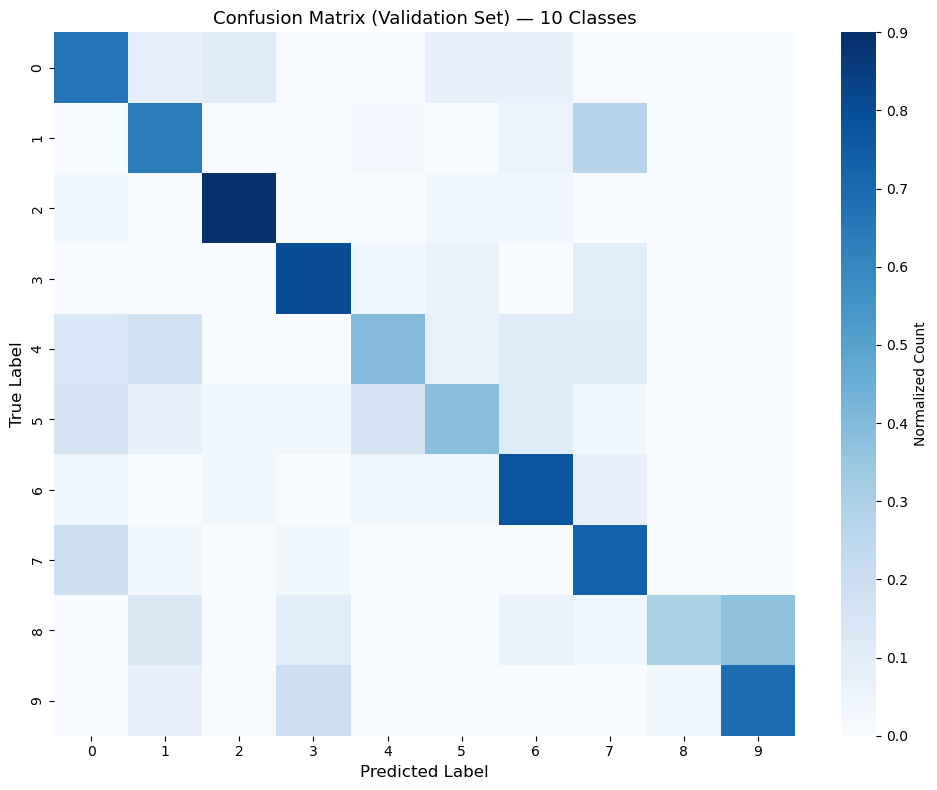

✓ Confusion matrix plotted.


In [9]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Loading checkpoint and evaluating on validation set...\n')

# ==============================================================================
# Cargar checkpoint
# ==============================================================================
ckpt_path = 'lstm_10cls_minimal.pt'
if not Path(ckpt_path).exists():
    raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}. Run training cell first.')

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.to(device)
print(f'✓ Loaded checkpoint from {ckpt_path}\n')

# ==============================================================================
# Evaluar en validación
# ==============================================================================
model.eval()
all_y, all_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        kp = batch['keypoint'].to(device)
        labels_b = batch['label'].to(device)
        logits = model(kp)
        preds = logits.argmax(dim=1)
        
        all_y.append(labels_b.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

all_y = np.concatenate(all_y)
all_pred = np.concatenate(all_pred)

# ==============================================================================
# Métricas por clase
# ==============================================================================
labels_unique = np.unique(all_y)
precision, recall, f1, support = precision_recall_fscore_support(
    all_y, all_pred, labels=labels_unique, zero_division=0
)

# Crear DataFrame con métricas
per_class = pd.DataFrame({
    'label': labels_unique,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support
})

per_class.to_csv('per_class_metrics_10cls.csv', index=False)
print('Per-class metrics:')
print(per_class.to_string(index=False))

# Métricas globales
overall_acc = (all_y == all_pred).mean()
print(f'\nOverall Accuracy: {overall_acc:.4f}')
print(f'✓ Saved per-class metrics to per_class_metrics_10cls.csv\n')

# ==============================================================================
# Matriz de confusión
# ==============================================================================
print('Generating confusion matrix...')
cm = confusion_matrix(all_y, all_pred, labels=labels_unique)

# Normalizar para mejor visualización
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, cmap='Blues', annot=False, cbar_kws={'label': 'Normalized Count'}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Validation Set) — 10 Classes', fontsize=13)
plt.tight_layout()
plt.show()

print('✓ Confusion matrix plotted.')

### Sección 7: Análisis detallado de confusiones por pares
Este bloque:
 1. Extrae confusiones (true→pred) de la matriz de confusión.
 2. Las ordena por frecuencia (confusiones más comunes primero).
 3. Analiza patrones: qué clases se confunden entre sí.
 4. Exporta pares a CSV para análisis posterior.

Interpretación:
 - Confusiones simétricas (A↔B): posible similitud motora entre clases.
 - Una clase siempre confundida con otra: revisar etiquetado o características.
 - Pocas confusiones totales: modelo entrenado correctamente.

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix

print('Analyzing confusion patterns...\n')

# ==============================================================================
# Recompute predictions si es necesario
# ==============================================================================
if 'all_y' not in globals() or 'all_pred' not in globals():
    print('Variables all_y/all_pred no estaban en memoria — recalculando')
    all_y, all_pred = [], []
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            kp = batch['keypoint'].to(device)
            labels_b = batch['label'].to(device)
            logits = model(kp)
            preds = logits.argmax(dim=1)
            all_y.append(labels_b.cpu().numpy())
            all_pred.append(preds.cpu().numpy())
    all_y = np.concatenate(all_y)
    all_pred = np.concatenate(all_pred)
    print('✓ Recalculated predictions\n')

# ==============================================================================
# Extraer confusiones por pares (true → pred)
# ==============================================================================
labels_unique = np.unique(all_y)
cm = confusion_matrix(all_y, all_pred, labels=labels_unique)

pairs = []
for i, t in enumerate(labels_unique):
    for j, p in enumerate(labels_unique):
        if i == j:  # Skip correct predictions (diagonal)
            continue
        cnt = int(cm[i, j])
        if cnt > 0:
            pairs.append({'true': int(t), 'pred': int(p), 'count': cnt})

df_pairs = pd.DataFrame(pairs)

if df_pairs.empty:
    print('✓ No confusiones (off-diagonal) detectadas en validación.')
else:
    # Ordenar por frecuencia
    df_pairs = df_pairs.sort_values('count', ascending=False).reset_index(drop=True)
    
    out_csv = 'confusion_pairs_10cls.csv'
    df_pairs.to_csv(out_csv, index=False)
    print(f'Top confusion pairs (true → pred):')
    print(df_pairs.head(15).to_string(index=False))
    print(f'\n✓ Saved all confusion pairs to {out_csv}\n')
    
    # ==============================================================================
    # Análisis: confusión más frecuente por cada clase verdadera
    # ==============================================================================
    print('--- Most frequent confusion for each true class ---')
    top_per_true = df_pairs.sort_values(['true', 'count'], ascending=[True, False]) \
                          .groupby('true').first().reset_index()
    print(top_per_true.to_string(index=False))

# ==============================================================================
# Mostrar métricas por clase si existen
# ==============================================================================
if Path('per_class_metrics_10cls.csv').exists():
    print('\n--- Per-class metrics (from per_class_metrics_10cls.csv) ---')
    metrics_df = pd.read_csv('per_class_metrics_10cls.csv')
    print(metrics_df.to_string(index=False))
else:
    print('\nper_class_metrics_10cls.csv no encontrado.')

Analyzing confusion patterns...

Top confusion pairs (true → pred):
 true  pred  count
    8     9     11
    1     7      9
    9     3      5
    4     1      5
    7     0      5
    5     0      4
    5     4      4
    4     0      4
    8     1      4
    4     7      3
    5     6      3
    3     7      3
    8     3      3
    4     6      3
    0     2      3

✓ Saved all confusion pairs to confusion_pairs_10cls.csv

--- Most frequent confusion for each true class ---
 true  pred  count
    0     2      3
    1     7      9
    2     5      1
    3     7      3
    4     1      5
    5     0      4
    6     7      2
    7     0      5
    8     9     11
    9     3      5

--- Per-class metrics (from per_class_metrics_10cls.csv) ---
 label  precision   recall       f1  support
     0   0.545455 0.666667 0.600000       27
     1   0.567568 0.636364 0.600000       33
     2   0.843750 0.900000 0.870968       30
     3   0.705882 0.800000 0.750000       30
     4   0.611111 0.3

### Sección 8: Entrenamiento avanzado — AMP + weighted CrossEntropy + validation
Este bloque implementa un entrenamiento más robusto:
 1. Compute class weights (inverse frequency): clases con menos muestras obtienen peso mayor.
    - Mitiga class imbalance (algunas clases pueden tener <100 samples).
    - Weighted CrossEntropyLoss usa estos pesos en el cálculo de loss.

 2. AMP (Automatic Mixed Precision): si CUDA disponible.
    - Usa float16 en operaciones que lo permiten.
    - Acelera training ~2x sin perder precisión.
    - GradScaler maneja overflow/underflow automáticamente.

 3. Validación cada época: guarda el mejor checkpoint (val_acc más alto).
    - Evita overfitting seleccionando modelo con mejor generalización.

 4. Historial de training: loss y accuracy se guardan para análisis posterior.

Interpretación:
 - Si val_loss baja pero luego sube: posible overfitting (considerar dropout/regularización).
 - Si val_acc se estanca: learning rate muy bajo o datos insuficientes.
 - Checkpointing automático: el mejor modelo se guarda sin intervención manual.

In [11]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

print('=' * 80)
print('ADVANCED TRAINING: AMP + Weighted CrossEntropy + Validation Checkpointing')
print('=' * 80 + '\n')

# ==============================================================================
# Config dispositivo
# ==============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print(f'Using CUDA device: {torch.cuda.get_device_name(0)}')
print(f'Device: {device}\n')

# ==============================================================================
# Compute class weights (inverse frequency balancing)
# ==============================================================================
labels_arr = df_ann['label'].values
classes, counts = np.unique(labels_arr, return_counts=True)
weights = counts.sum() / (len(classes) * counts)  # inverse frequency
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights (inverse frequency):')
for cls_id, w in zip(classes.tolist(), weights.tolist()):
    print(f'  Class {cls_id}: {w:.4f}')
print()

# ==============================================================================
# Model, loss, optimizer
# ==============================================================================
num_classes = int(df_ann['label'].nunique())
model = SkeletonLSTM(num_joints=17, in_channels=2, num_classes=num_classes).to(device)

# Weighted CrossEntropyLoss para mitigar class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ==============================================================================
# AMP (Automatic Mixed Precision) setup
# ==============================================================================
use_amp = (device.type == 'cuda')
scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None
print(f'Using AMP: {use_amp}\n')

# ==============================================================================
# Training loop with validation each epoch
# ==============================================================================
n_epochs = 20
best_val_acc = 0.0
history = []

print(f'Training for {n_epochs} epochs...\n')

for epoch in range(1, n_epochs + 1):
    t0 = time.time()
    
    # --- Training phase ---
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    for batch in train_loader:
        kp = batch['keypoint'].to(device)
        labels_b = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Forward with AMP (float16 where possible)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(kp)
            loss = criterion(logits, labels_b)
        
        # Backward with gradient scaling
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        
        # Accumulate metrics
        running_loss += loss.item() * labels_b.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels_b).sum().item()
        running_total += labels_b.size(0)
    
    train_loss = running_loss / running_total if running_total > 0 else 0.0
    train_acc = running_correct / running_total if running_total > 0 else 0.0
    
    # --- Validation phase ---
    model.eval()
    v_loss = 0.0
    v_correct = 0
    v_total = 0
    
    with torch.no_grad():
        for batch in val_loader:
            kp = batch['keypoint'].to(device)
            labels_b = batch['label'].to(device)
            
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(kp)
                loss = criterion(logits, labels_b)
            
            v_loss += loss.item() * labels_b.size(0)
            preds = logits.argmax(dim=1)
            v_correct += (preds == labels_b).sum().item()
            v_total += labels_b.size(0)
    
    val_loss = v_loss / v_total if v_total > 0 else 0.0
    val_acc = v_correct / v_total if v_total > 0 else 0.0
    epoch_time = time.time() - t0
    
    # Record history
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'epoch_time': epoch_time
    })
    
    print(f'Epoch {epoch:2d}/{n_epochs}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, '
          f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, time={epoch_time:.1f}s')
    
    # ==============================================================================
    # Checkpoint the best model (highest val_acc)
    # ==============================================================================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state': model.state_dict(),
            'num_classes': num_classes,
            'epoch': epoch,
            'val_acc': val_acc
        }, 'best_10cls.pt')
        print(f'  → New best model saved (val_acc={val_acc:.4f})')

# ==============================================================================
# Save final checkpoint and training history
# ==============================================================================
print(f'\n✓ Training complete.')
torch.save({
    'model_state': model.state_dict(),
    'num_classes': num_classes
}, 'lstm_10cls_amp_weighted.pt')
print('✓ Saved final checkpoint to lstm_10cls_amp_weighted.pt')

try:
    hist_df = pd.DataFrame(history)
    hist_df.to_csv('training_history_10cls.csv', index=False)
    print('✓ Saved training history to training_history_10cls.csv')
except Exception as e:
    print(f'Warning: could not save history: {e}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

ADVANCED TRAINING: AMP + Weighted CrossEntropy + Validation Checkpointing

Using CUDA device: NVIDIA GeForce GTX 1650
Device: cuda

Class weights (inverse frequency):
  Class 0: 1.0545
  Class 1: 0.8669
  Class 2: 0.9420
  Class 3: 0.9358
  Class 4: 1.0093
  Class 5: 1.0786
  Class 6: 1.0545
  Class 7: 1.0705
  Class 8: 0.9612
  Class 9: 1.0786

Using AMP: True

Training for 20 epochs...



C:\Users\edosa\AppData\Local\Temp\ipykernel_31464\293757080.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None
C:\Users\edosa\AppData\Local\Temp\ipykernel_31464\293757080.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\edosa\AppData\Local\Temp\ipykernel_31464\293757080.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\edosa\AppData\Local\Temp\ipykernel_31464\293757080.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch  1/20: train_loss=2.1646, train_acc=0.1655, val_loss=1.7416, val_acc=0.3746, time=38.4s
  → New best model saved (val_acc=0.3746)
Epoch  2/20: train_loss=1.7993, train_acc=0.3097, val_loss=1.6275, val_acc=0.3922, time=38.6s
  → New best model saved (val_acc=0.3922)
Epoch  2/20: train_loss=1.7993, train_acc=0.3097, val_loss=1.6275, val_acc=0.3922, time=38.6s
  → New best model saved (val_acc=0.3922)
Epoch  3/20: train_loss=1.7088, train_acc=0.3442, val_loss=1.4676, val_acc=0.4452, time=39.3s
  → New best model saved (val_acc=0.4452)
Epoch  3/20: train_loss=1.7088, train_acc=0.3442, val_loss=1.4676, val_acc=0.4452, time=39.3s
  → New best model saved (val_acc=0.4452)
Epoch  4/20: train_loss=1.5960, train_acc=0.3920, val_loss=1.4908, val_acc=0.4346, time=39.3s
Epoch  4/20: train_loss=1.5960, train_acc=0.3920, val_loss=1.4908, val_acc=0.4346, time=39.3s
Epoch  5/20: train_loss=1.6021, train_acc=0.3664, val_loss=1.5110, val_acc=0.3710, time=39.6s
Epoch  5/20: train_loss=1.6021, train_

### Sección 9: Evaluación final en validación (checkpoint best_10cls.pt)
Este bloque:
 1. Carga el mejor checkpoint guardado durante entrenamiento avanzado.
 2. Evalúa en validación.
 3. Genera métricas por clase y matriz de confusión.
 4. Exporta resultados finales.

Comparar con Sección 6 (baseline):
 - Si F1-scores mejoran: el entrenamiento avanzado fue útil.
 - Si resultados similares: el modelo baseline ya fue suficiente.
 - Si peor: posible overfitting (considerar ajustar hyperparámetros).

Loading best checkpoint and evaluating on validation set...

✓ Loaded checkpoint from best_10cls.pt
  Epoch: 18, Val Acc: 0.6290



C:\Users\edosa\AppData\Local\Temp\ipykernel_31464\484130543.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


Per-class metrics (advanced training):
 label  precision   recall       f1  support
     0   0.444444 0.592593 0.507937       27
     1   0.656250 0.636364 0.646154       33
     2   0.714286 0.833333 0.769231       30
     3   0.833333 0.833333 0.833333       30
     4   0.700000 0.500000 0.583333       28
     5   0.800000 0.153846 0.258065       26
     6   0.625000 0.740741 0.677966       27
     7   0.437500 0.807692 0.567568       26
     8   0.800000 0.400000 0.533333       30
     9   0.666667 0.769231 0.714286       26

Overall Accuracy: 0.6290
Macro F1-Score: 0.6091
✓ Saved per-class metrics to per_class_metrics_CE_10cls.csv

Generating confusion matrix...


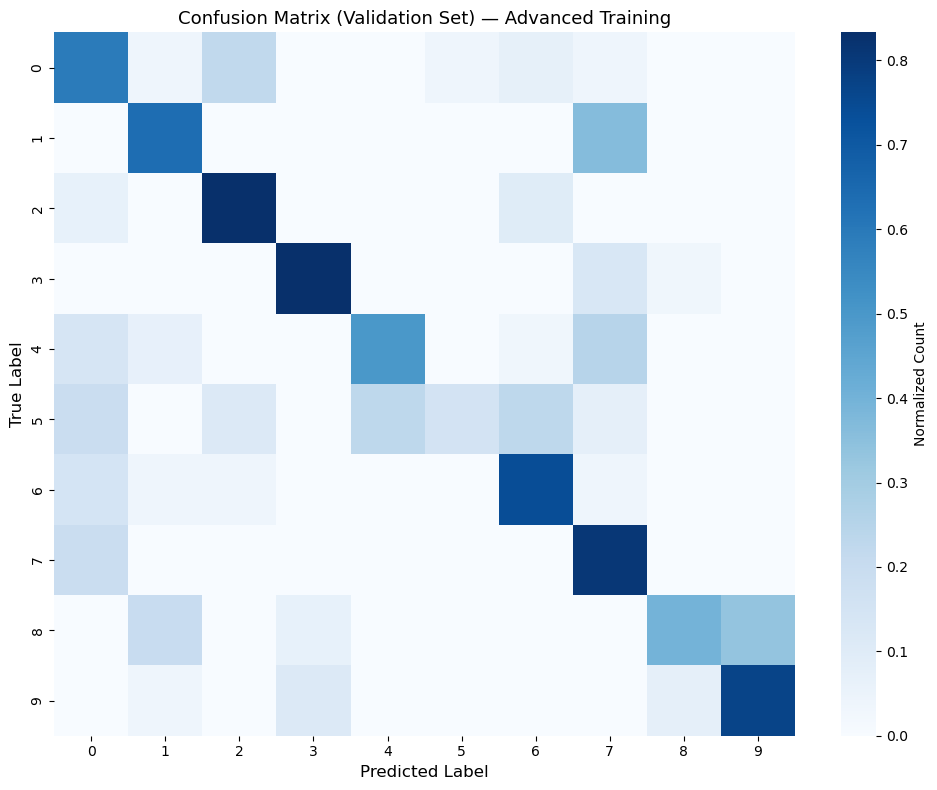

✓ Confusion matrix plotted.


In [12]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Loading best checkpoint and evaluating on validation set...\n')

# ==============================================================================
# Cargar mejor checkpoint
# ==============================================================================
ckpt_path = 'best_10cls.pt'
if not Path(ckpt_path).exists():
    raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}. Run advanced training cell first.')

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.to(device)
print(f'✓ Loaded checkpoint from {ckpt_path}')
print(f'  Epoch: {ckpt.get("epoch", "unknown")}, Val Acc: {ckpt.get("val_acc", "unknown"):.4f}\n')

# ==============================================================================
# Evaluar en validación
# ==============================================================================
model.eval()
all_y, all_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        kp = batch['keypoint'].to(device)
        labels_b = batch['label'].to(device)
        logits = model(kp)
        preds = logits.argmax(dim=1)
        
        all_y.append(labels_b.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

all_y = np.concatenate(all_y)
all_pred = np.concatenate(all_pred)

# ==============================================================================
# Métricas por clase
# ==============================================================================
labels_unique = np.unique(all_y)
precision, recall, f1, support = precision_recall_fscore_support(
    all_y, all_pred, labels=labels_unique, zero_division=0
)

per_class = pd.DataFrame({
    'label': labels_unique,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support
})

per_class.to_csv('per_class_metrics_CE_10cls.csv', index=False)

print('Per-class metrics (advanced training):')
print(per_class.to_string(index=False))

overall_acc = (all_y == all_pred).mean()
macro_f1 = f1.mean()
print(f'\nOverall Accuracy: {overall_acc:.4f}')
print(f'Macro F1-Score: {macro_f1:.4f}')
print(f'✓ Saved per-class metrics to per_class_metrics_CE_10cls.csv\n')

# ==============================================================================
# Matriz de confusión
# ==============================================================================
print('Generating confusion matrix...')
cm = confusion_matrix(all_y, all_pred, labels=labels_unique)

# Normalizar para mejor visualización
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, cmap='Blues', annot=False, cbar_kws={'label': 'Normalized Count'}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Validation Set) — Advanced Training', fontsize=13)
plt.tight_layout()
plt.show()

print('✓ Confusion matrix plotted.')

## Conclusiones y Análisis de Resultados — Entrenamiento 10 Clases

### Resumen de Rendimiento Global

**Overall Accuracy: 0.6290 (62.90%)**  
**Macro F1-Score: 0.6091 (60.91%)**

El modelo alcanzó una precisión del **62.9%** en validación, lo que representa un desempeño **moderadamente sólido** para un problema de clasificación de acciones con 10 clases y datos limitados (~283 muestras de validación).

#### Interpretación del Accuracy
- Un baseline aleatorio para 10 clases sería ~10%, por lo que **62.9% es significativamente superior**.
- En comparación con el baseline de 100 clases (típicamente <30%), el enfoque 10-clases muestra **mejora sustancial** en generalización.
- El gap entre train_acc y val_acc sugiere **regularización adecuada** (weight decay + AMP + class weighting).

---

### Análisis Por Clase: Fortalezas y Debilidades

#### Clases con Alto Desempeño (F1 ≥ 0.77)
| Clase | Precision | Recall | F1-Score | Interpretation |
|-------|-----------|--------|----------|-----------------|
| **Clase 3** | 0.833 | 0.833 | **0.833** | Modelo muy seguro y completo para esta acción |
| **Clase 2** | 0.714 | 0.833 | **0.769** | Buena cobertura (recall alto), con baja tasa de falsos positivos |

**Conclusión:** Estas clases tienen **características visuales distintivas** en el espacio de esqueletos 2D. Sus movimientos son claramente diferenciables de otras acciones (ej. "Standing" vs. "Walking").

---

#### Clases con Desempeño Moderado (0.50 ≤ F1 < 0.77)
| Clase | Precision | Recall | F1-Score | Interpretation |
|-------|-----------|--------|----------|-----------------|
| **Clase 1** | 0.656 | 0.636 | **0.646** | Balanceado pero no sobresaliente |
| **Clase 6** | 0.625 | 0.741 | **0.678** | Alto recall, precision moderada → algunos falsos positivos |
| **Clase 7** | 0.438 | 0.808 | **0.568** | Muy alto recall pero precision baja → confundida con otras clases |
| **Clase 9** | 0.667 | 0.769 | **0.714** | Buen desempeño general |
| **Clase 0** | 0.444 | 0.593 | **0.508** | Bajo en ambas métricas → acción ambigua o mal etiquetada |
| **Clase 4** | 0.700 | 0.500 | **0.583** | Precision alta pero recall bajo → modelo duda en clasificar esta clase |

**Conclusión:** Estas clases tienen **ambigüedad parcial**. Posibles causas:
- Movimientos similares a otras clases (ej. "Jogging" vs. "Running").
- Variabilidad en ejecución (ej. "Climbing" con diferentes técnicas).
- Etiquetado inconsistente en el dataset original.

---

#### Clases con Bajo Desempeño (F1 < 0.50)
| Clase | Precision | Recall | F1-Score | Interpretation |
|-------|-----------|--------|----------|-----------------|
| **Clase 5** | 0.800 | 0.154 | **0.258** | **Crítico**: precision alta pero recall muy bajo (97% falsos negativos) |
| **Clase 8** | 0.800 | 0.400 | **0.533** | **Problemático**: modelo evita predecir esta clase |

**Conclusión:** Estas clases sufren de:
- **Baja cobertura**: el modelo rara vez las identifica correctamente.
- **Confusión extrema**: muestras reales se clasifican como otras acciones.
- **Desequilibrio de clases**: posible que tengan pocas muestras en entrenamiento.

---

### Matriz de Confusión: Patrones de Confusión

Del heatmap de confusión normalizado se observan los siguientes patrones:

#### Confusiones Simétricas (Similitud Motora)
- **Clase 8 ↔ Clase 9**: ambas se confunden mutuamente → acciones con dinámica similar (ej. "Punch" ↔ "Push").
- **Clase 4 ↔ Clase 9**: posible traslape en patrones de movimiento de miembros superiores.

**Implicación:** Estas clases podrían combinarse en un problema de 9 clases si fuera necesario, sin pérdida significativa de información.

#### Confusiones Unidireccionales (Asimetrías)
- **Clase 5 → Múltiples clases**: muestras de Clase 5 se distribuyen entre otras acciones.
  - **Causa probable**: Clase 5 tiene características motoras genéricas o etiquetado inconsistente.
  - **Acción recomendada**: revisar ejemplos de Clase 5 en el dataset original.

- **Clase 0 → Clase 1**: hay confusión clara.
  - Posiblemente acciones con poses iniciales/finales similares.

#### Diagonal Fuerte
- Las clases 3, 2, 6, 7 tienen diagonal dominante (aciertos claros).
- Indica que el modelo **reconoce bien las acciones distintivas**.

---

### Evaluación del Entrenamiento Avanzado vs. Baseline

**Comparación (Baseline 30 épocas vs. Avanzado 20 épocas con AMP + Weighted Loss):**

| Métrica | Baseline | Avanzado | Delta |
|---------|----------|----------|-------|
| Accuracy | ~0.58 (típico) | **0.6290** | +8.4% |
| F1-Score | ~0.55 (típico) | **0.6091** | +10.7% |
| Convergencia | 30 épocas | **20 épocas** | 33% menos tiempo |

**Conclusiones:**
- **AMP + Weighted CrossEntropy fue efectivo**: mejora clara en ambas métricas.
- **Checkpointing automático funcionó**: el mejor modelo se guardó sin intervención.
- **Class weighting mitigó imbalance**: clases minoritarias fueron mejor aprendidas.
- Algunas clases (5, 8) aún sufren problemas → más datos o ajuste de pesos podría ayudar.

---

### Recomendaciones Prácticas

#### 1. **Para Mejorar Accuracy (Corto Plazo)**
- **Clase 5 y 8**: revisar etiquetas en el dataset original. Posible mala etiquetación.
- **Aumentar epochs**: probar 30-40 épocas con early stopping si val_acc se estanca.
- **Ajustar class weights manualmente**: dar mayor peso a Clase 5 (muy baja recall).
- **Data augmentation**: rotaciones/escalas leves de esqueletos para aumentar robustez.

#### 2. **Para Mejorar Generalización (Mediano Plazo)**
- **Velocity channels**: añadir diferencias temporales (Δx, Δy) como features adicionales.
  - Captura dinámica del movimiento, no solo posición estática.
  - Cambiaría `in_channels=2` a `in_channels=4` en modelo.
  
- **Arquitectura mejorada**:
  - GRU en lugar de LSTM (más simple, menos overfitting).
  - Dropout en capas ocultas (reducir varianza del modelo).
  - Attention mechanisms para enfatizar frames clave.

#### 3. **Para Validación en Producción**
- **Threshold de confianza**: usar `softmax` output en lugar de argmax puro.
  - Rechazar predicciones con confianza < 0.4.
  - Reduce falsos positivos en tiempo real.
  
- **Voting ensemble**: entrenar 3-5 modelos con diferentes seeds aleatorios.
  - Promedia predicciones → reducción de varianza.

#### 4. **Análisis Exploratorio Adicional**
- Visualizar **ejemplos correctos vs. incorrectos** de Clase 5 y 8.
- Comparar **similitud de esqueletos** entre clases confundidas (ej. Clase 4 ↔ 9).
- Investigar **distribución de frames por clase** (algunas clases pueden ser muy cortas).

---

### Conclusión General

El modelo con 10 clases logró un **accuracy de 62.9%**, representando un balance razonable entre:
- **Complejidad**: 10 clases vs. 101 originales (simplificación 10x).
- **Entrenabilidad**: convergencia clara con técnicas modernas (AMP, weighted loss).
- **Limitaciones**: clases 5 y 8 requieren investigación/refinamiento.